In [53]:
from typing import Callable, Any
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from joblib import Parallel, delayed, dump, load
import numpy as np
import random

sns.set_theme(
    context="notebook",
    style="whitegrid",
    font="sans-serif",
)

## Pomocnicze funkcje do wizualizacji

In [54]:
def plot_sudoku(board: np.ndarray, mask: np.ndarray, ax = None):
    n, _ = board.shape

    independent = ax is None
    if independent:
        fig, ax = plt.subplots(figsize=(6, 6))

    pastel_cmap = ListedColormap(['white', '#C1E1C1'])
    ax.imshow(mask, cmap=pastel_cmap, vmin=0, vmax=1)
    
    ax.set_xticks(np.arange(-0.5, 9, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, 9, 1), minor=True)
    ax.grid(which='minor', color='black', linestyle='-', linewidth=1)
    
    ax.set_xticks(np.arange(-0.5, 9, 3), minor=False)
    ax.set_yticks(np.arange(-0.5, 9, 3), minor=False)
    ax.grid(which='major', color='black', linestyle='-', linewidth=2.5)
    
    ax.tick_params(which='both', bottom=False, left=False, labelbottom=False, labelleft=False)

    for i in range(n):
        for j in range(n):
            if board[i][j] != 0: 
                ax.text(j, i, str(int(board[i, j])),
                        ha="center", va="center", color="k", fontsize=16, fontweight='bold')
                
    ax.set_title(f"Number of free cells: {81 - np.sum(mask)}")
    
    if independent:
        fig.tight_layout()
        plt.show()

In [55]:
def plot_solution(min_energy: float, energy_log: list[float], temperature_log: list[float], board: np.ndarray, solution: np.ndarray, mask: np.ndarray, iterations: int, save_as: str | None = None):
    fig, (ax_energy, ax_board, ax_solution) = plt.subplots(nrows=1, ncols=3, figsize=(18, 5), layout="constrained")

    ax_energy.plot(energy_log, color='blue', alpha=0.8, label='Energy')
    ax_energy.set_title('Energy and Temperature over Time', fontweight='bold')
    ax_energy.set_xlabel('Epoch') 
    ax_energy.set_ylabel('Energy', color='blue')
    ax_energy.tick_params(axis='y', labelcolor='blue')
    ax_energy.grid(True, color='silver', linestyle='--', linewidth=0.7, alpha=0.7)

    ax_temp = ax_energy.twinx()
    ax_temp.plot(temperature_log, color='red', alpha=0.8, label='Temperature', zorder=5)
    ax_temp.set_ylabel('Temperature', color='red')
    ax_temp.tick_params(axis='y', labelcolor='red')

    plot_sudoku(board, mask, ax_board)
    plot_sudoku(solution, mask, ax_solution)

    fig.suptitle(
        f"Min energy: {min_energy}, Iterations: {iterations}",
        fontsize=16,
        y=1.05,
    )

    if save_as:
        plt.savefig(f"{save_as}.png")

    plt.show()

## Przygotowanie zbiorów sudoku

In [56]:
def prefill_board(board, mask):
    filled_grid = board.copy()
    
    for block_row in range(0, 9, 3):
        for block_col in range(0, 9, 3):
            block = filled_grid[block_row:block_row+3, block_col:block_col+3]
            existing_numbers = set(block.flatten())
            
            missing_numbers = list(set(range(1, 10)) - existing_numbers)
            random.shuffle(missing_numbers)
            
            for r in range(3):
                for c in range(3):
                    if mask[block_row + r, block_col + c] == 0:
                        filled_grid[block_row + r, block_col + c] = missing_numbers.pop()
                        
    return filled_grid

In [57]:
def load_sudoku_datasets(csv_path="./sudokus.csv"):
    datasets = []

    df = pd.read_csv(csv_path)

    for question in df['board']:
        line = str(question).strip()

        board = np.zeros((9, 9))
        mask = np.zeros((9, 9))

        for i, c in enumerate(line):
            row = i // 9
            col = i % 9

            if c == '.':
                continue
                
            board[row, col] = int(c)
            mask[row, col] = 1
        
        board = prefill_board(board, mask)
        datasets.append((board, mask))

    return datasets

In [58]:
datasets = load_sudoku_datasets()

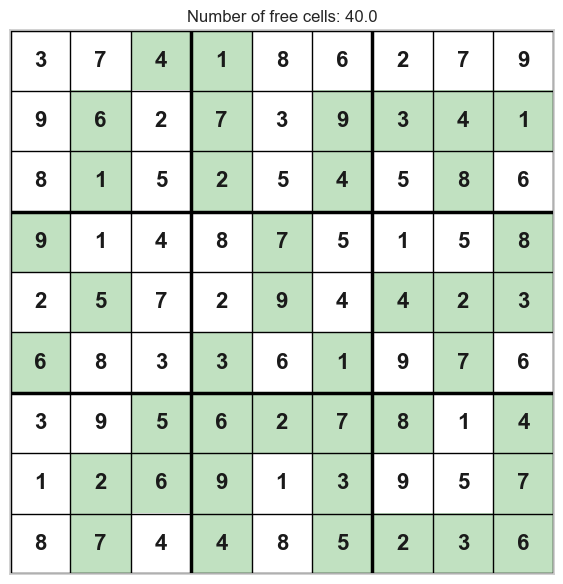

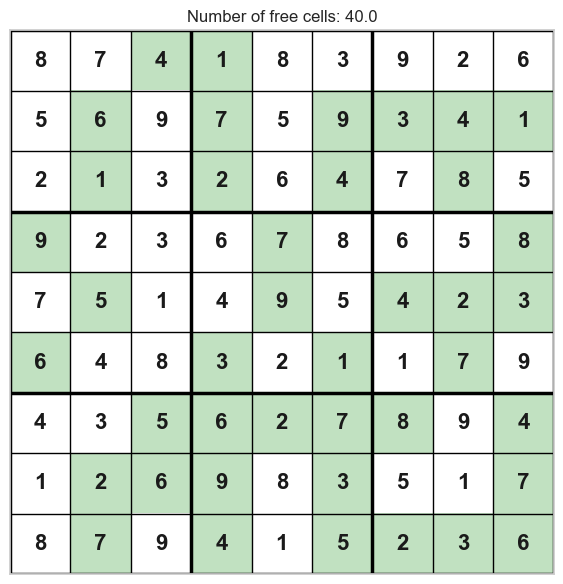

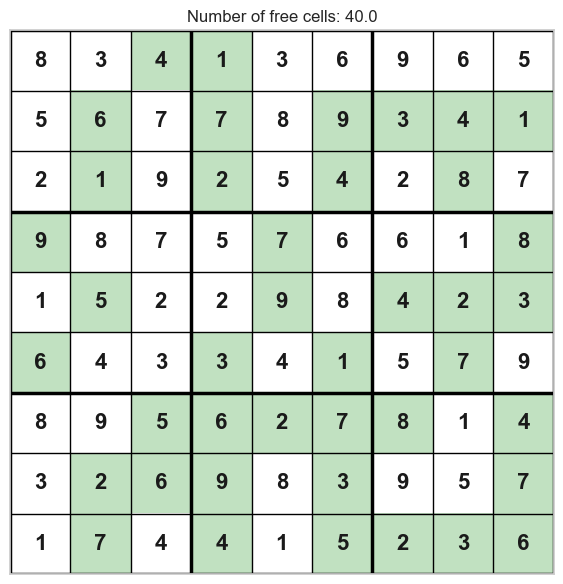

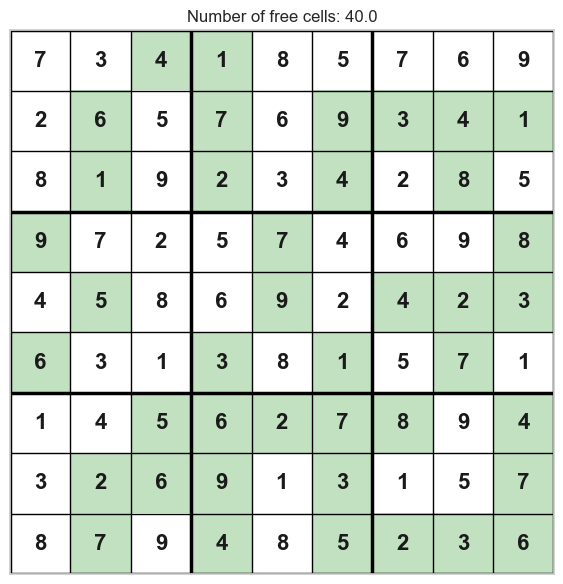

In [59]:
for board, mask in datasets[:4]:
    plot_sudoku(board, mask)

## Implementacja wyżarzania 

In [60]:
def annealing_schedule_exp(decay_factor: float = 0.9999):
    def schedule(t: float, _: int):
        return t * decay_factor

    return schedule

In [61]:
def estimate_initial_temperature(
    x: np.ndarray,
    mask: np.ndarray,
    delta_fn: Callable[[np.ndarray, np.ndarray], float],
    initial_acceptance = 0.8,
    iterations = 1000
) -> float:
    positive_energy_changes = 0
    no_positive_energy_changes = 0

    for _ in range(iterations):
        delta_y = delta_fn(x, mask)

        if delta_y > 0:
            no_positive_energy_changes += 1
            positive_energy_changes += delta_y

    positive_energy_changes /= no_positive_energy_changes
    t = -positive_energy_changes / np.log(initial_acceptance)

    return t

In [62]:
def energy(x: np.ndarray):
    cost = 0
    
    for i in range(9):
        cost += 9 - len(np.unique(x[i, :]))
        cost += 9 - len(np.unique(x[:, i]))
        
    for i in range(3):
        for j in range(3):
            block = x[i*3:(i+1)*3, j*3:(j+1)*3]
            cost += 9 - len(np.unique(block))
            
    return cost 

In [63]:
def transition(x: np.ndarray, mask: np.ndarray, energy: Callable[[np.ndarray], Any]) -> tuple[float, Callable[[], Any]]:
    free_cells = np.argwhere(mask == 0)
    
    idx1, idx2 = random.sample(range(len(free_cells)), 2)
    r1, c1 = free_cells[idx1]
    r2, c2 = free_cells[idx2]
    
    old_energy = energy(x)
    
    val1, val2 = x[r1, c1], x[r2, c2]
    x[r1, c1], x[r2, c2] = val2, val1
    
    new_energy = energy(x)
    
    x[r1, c1], x[r2, c2] = val1, val2
    delta_y = float(new_energy - old_energy)
    
    def apply():
        x[r1, c1], x[r2, c2] = val2, val1
        
    return delta_y, apply 

In [64]:
def annealing(
    x: np.ndarray,
    mask: np.ndarray,
    t: float,
    transition_fn: Callable[[np.ndarray, np.ndarray, np.ndarray], tuple[float, Callable[[np.ndarray], None]]],
    energy_fn: Callable[[np.ndarray], float],
    annealing_schedule: Callable[[float, int], float],
    hook_fn: Callable[[np.ndarray], None] | None = None,
    hook_step: int = 100,
    max_epochs: int = 25000,
    epoch_size: int = 50,
):
    y = energy_fn(x)
    x_best, y_best = x.copy(), y

    energy_log = [y]
    temp_log = [t]

    total_iterations = 0

    for epoch in range(max_epochs):
        if epoch % hook_step == 0 and hook_fn:
            hook_fn(x.copy())

        solved = False

        for _ in range(epoch_size):
            total_iterations += 1
            delta_y, apply = transition_fn(x, mask, energy_fn)

            if delta_y <= 0 or np.random.uniform() < np.exp(-delta_y / t):
                apply()
                y += delta_y

                if y < y_best:
                    x_best, y_best = x.copy(), y
                
                if y == 0:
                    solved = True
                    break

        energy_log.append(y)
        temp_log.append(t)
        t = annealing_schedule(t, epoch)

        if solved:
            break

        if t < 1e-12:
            break

    if hook_fn:
        hook_fn(x_best)

    return x_best, y_best, energy_log, temp_log, total_iterations

In [65]:
def run():
    def process_dataset(dataset, mask):
        t = estimate_initial_temperature(
            x=dataset,
            mask=mask,
            delta_fn=lambda x, m: transition(x, m, energy)[0]
        )
    
        return dataset.copy(), mask, annealing(
            x=dataset,
            mask=mask,
            t=t,
            transition_fn=transition,
            energy_fn=energy,
            annealing_schedule=annealing_schedule_exp(0.9995)
        )
    
    print("processing ...")
    results = Parallel(n_jobs=-1)(
        delayed(process_dataset)(dataset, mask) for dataset, mask in datasets
    )
    
    iterations_per_empty = {}

    for _, mask, (_, y, _, _, total_iterations) in results:
        if y == 0:
            iterations_per_empty[81 - np.sum(mask)] = total_iterations 
    
    data = {
        "results": results,
        "iterations_per_empty": iterations_per_empty
    }
    
    print("saving results ...")
    dump(data, "annealing_results.joblib")

In [66]:
# run()

In [67]:
data = load("annealing_results.joblib")
results = data["results"]
iterations_per_empty = data["iterations_per_empty"]

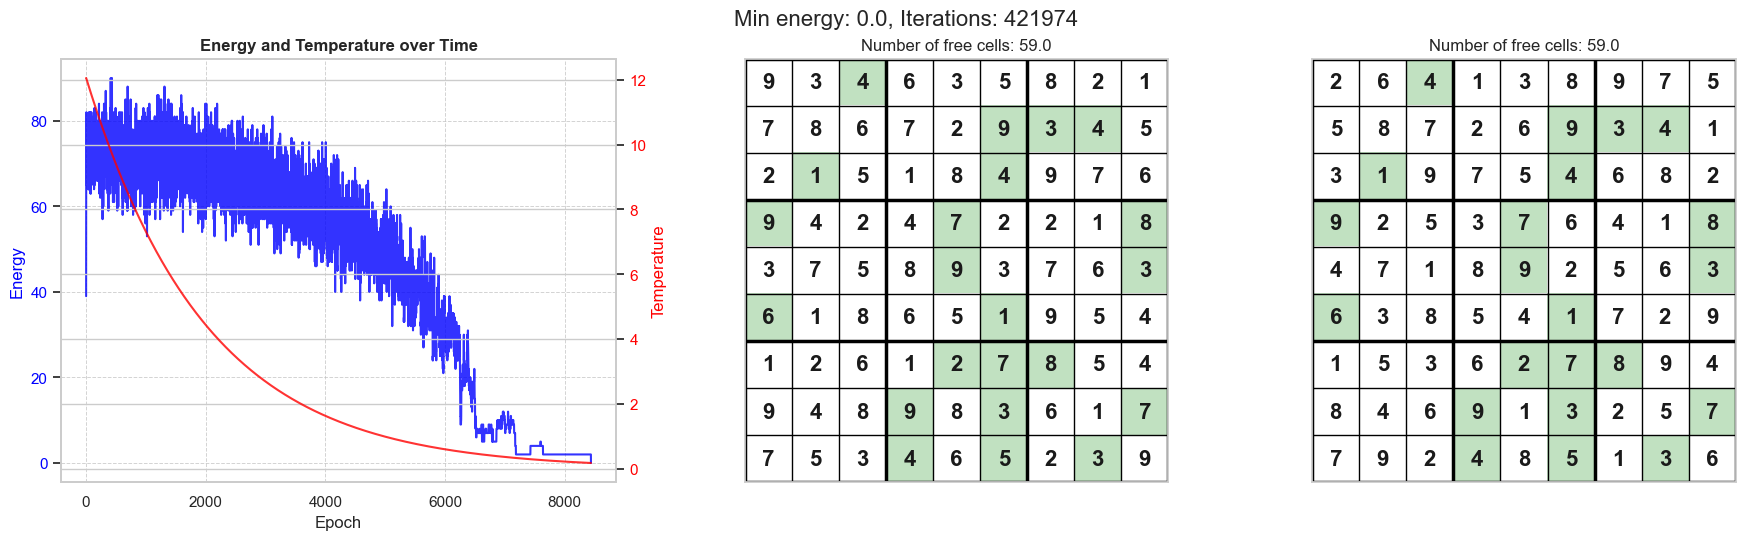

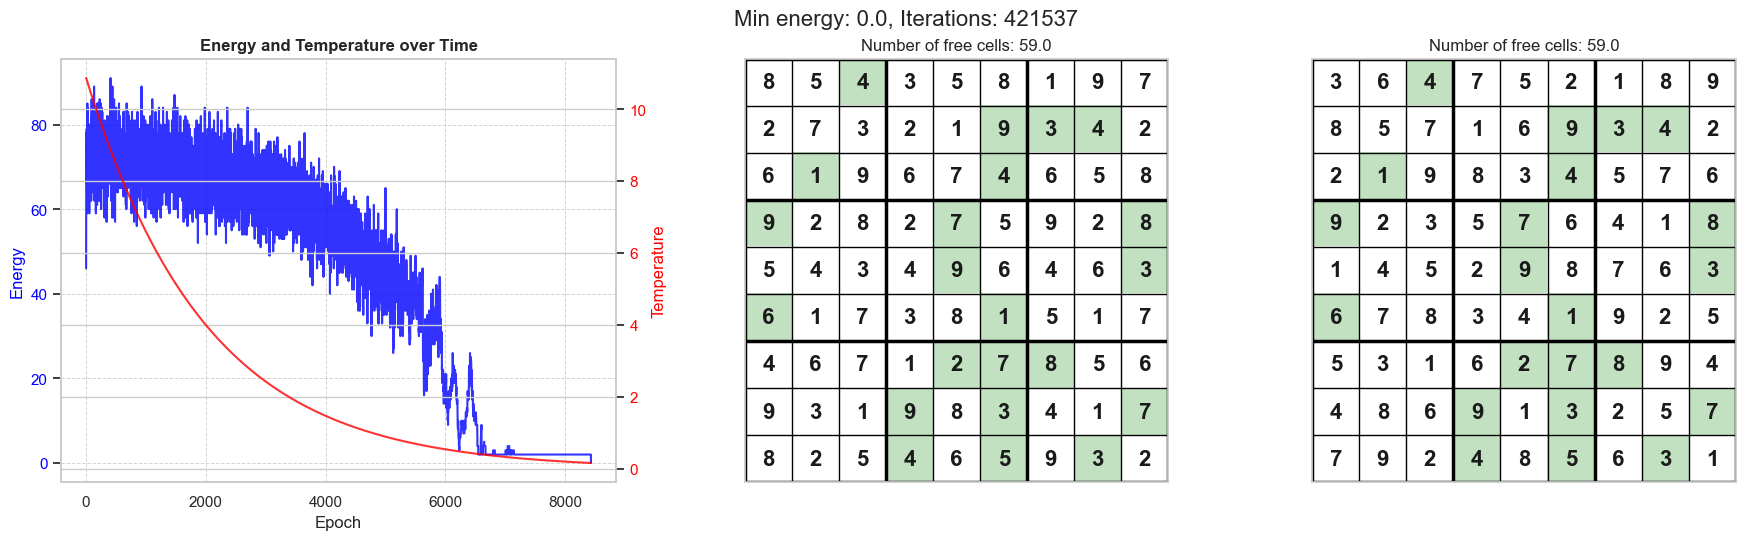

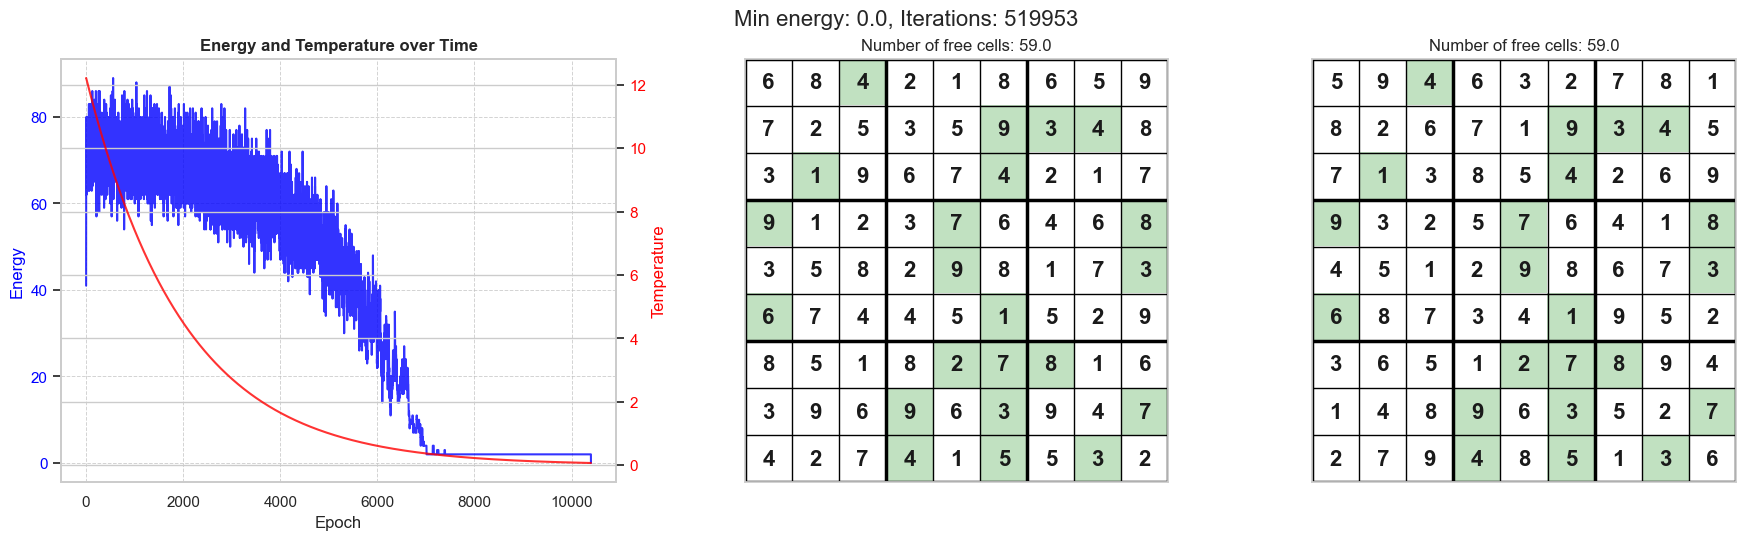

In [68]:
for board, mask, (solution, y, energy_log, temp_log, total_iterations) in results[-35:-32]:
    plot_solution(y, energy_log, temp_log, board, solution, mask, total_iterations)

Nie wszystkie przykłady zostały rozwiązane. Jeżeli temperatura spadnie do bardzo niskich wartości, gdy dalej brakuje kilku zamian, to algorytm może mieć problem z "trafieniem".

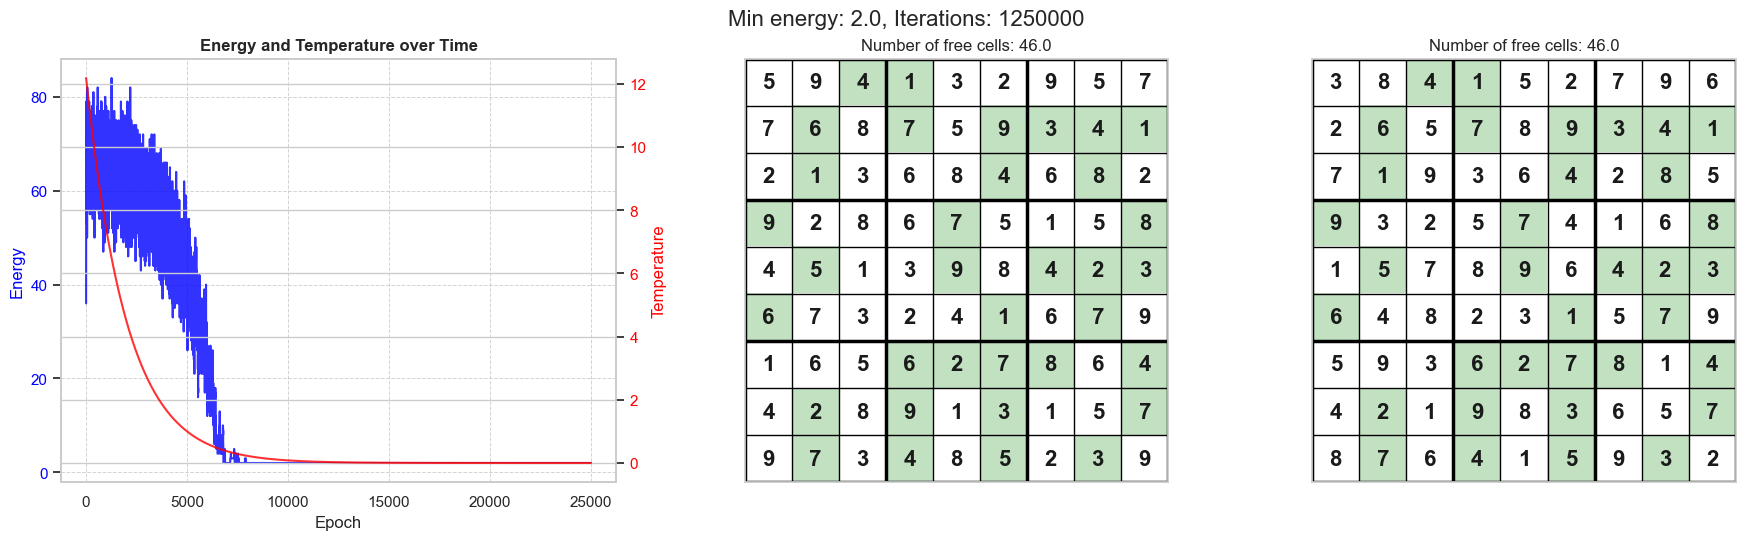

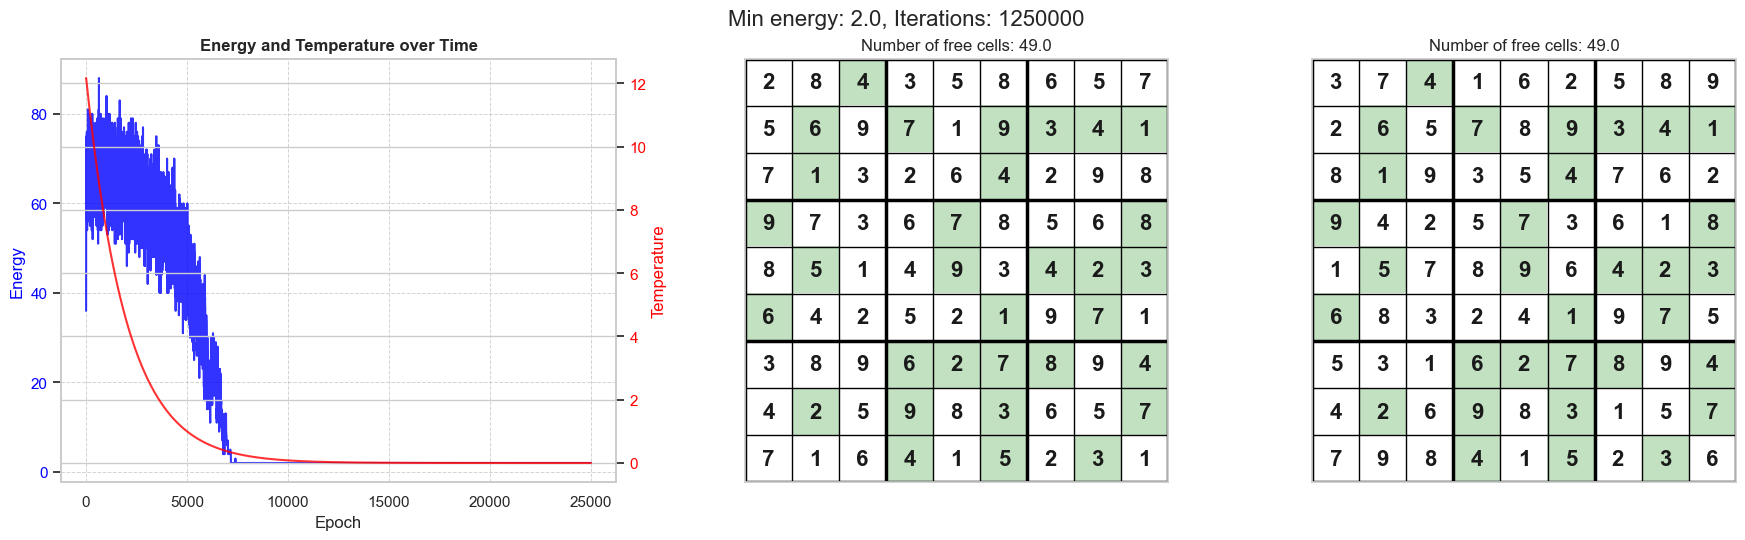

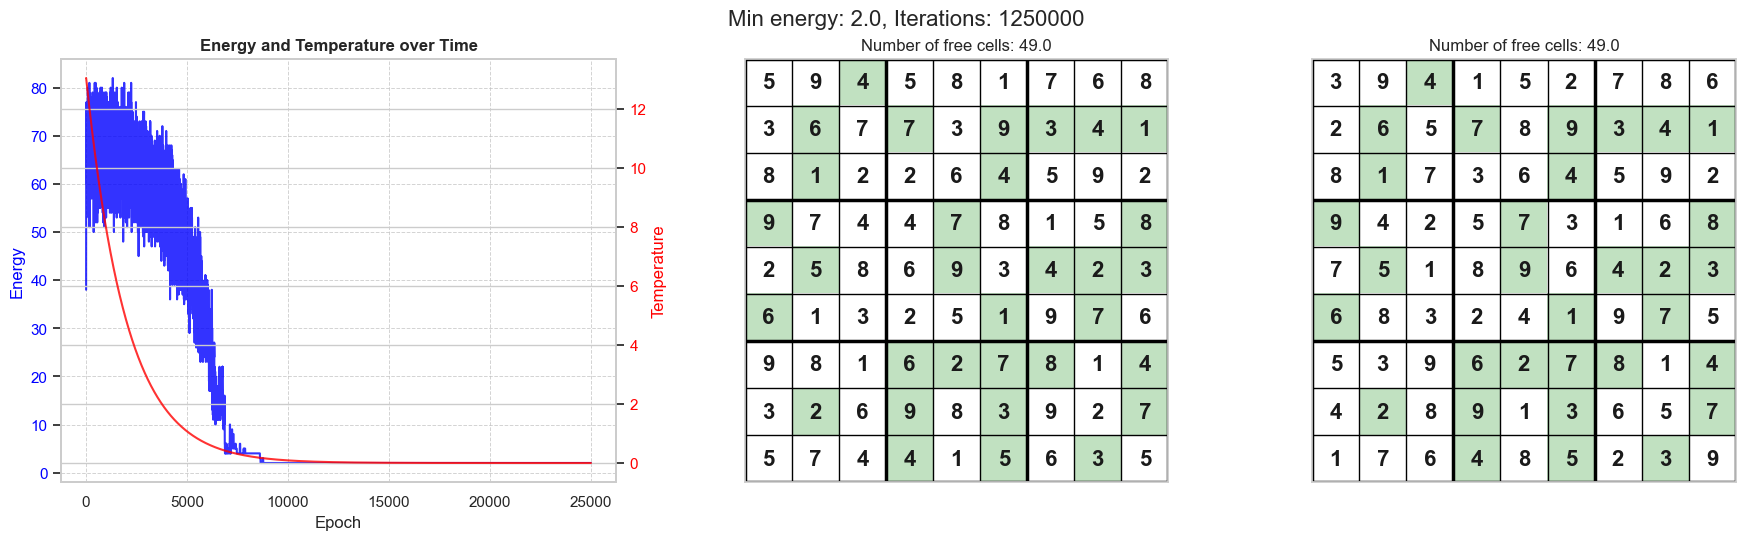

In [69]:
_tmp = 0

for board, mask, (solution, y, energy_log, temp_log, total_iterations) in results:
    if y > 0:
        plot_solution(y, energy_log, temp_log, board, solution, mask, total_iterations)
        _tmp += 1

        if _tmp == 3:
            break

## Porównanie ilości iteracji względem ilości pustych miejsc

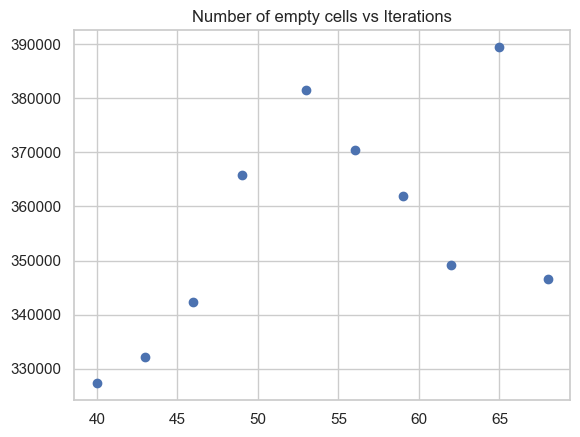

In [70]:
plt.title("Number of empty cells vs Iterations")
plt.scatter(iterations_per_empty.keys(), iterations_per_empty.values())